# PROCESS 2

## Import libraries


In [1]:
from graphviz import Digraph
from IPython.display import Image

## Introduce about graphviz

clause : -a -b c

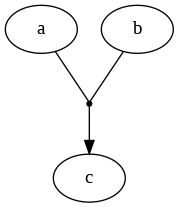

In [2]:
dot = Digraph()

dot.node('a', label = 'a')
dot.node('b', label = 'b')
dot.node('c')
dot.node('dot', shape = 'point')

dot.edge('a', 'dot', arrowhead = 'none')
dot.edge('b', 'dot', arrowhead = 'none')
dot.edge('dot', 'c')

dot.render('negated_implication_1', format = 'png', view = True)

Image(filename='negated_implication_1.png')

clause : -b -c -d e

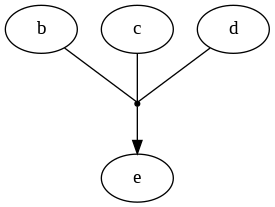

In [3]:
dot = Digraph()

dot.node('b', label = 'b')
dot.node('c', label = 'c')
dot.node('d', label = 'd')
dot.node('e')
dot.node('dot', shape = 'point')

dot.edge('b', 'dot', arrowhead = 'none')
dot.edge('c', 'dot', arrowhead = 'none')
dot.edge('d', 'dot', arrowhead = 'none')
dot.edge('dot', 'e')

dot.render('negated_implication_2', format = 'png', view = True)

Image(filename='negated_implication_2.png')

## Defining Clause class

In [4]:
class Clause:
  def __init__(self, premise, conclusion):
    self.premise = premise  # list of symbols
    self.conclusion = conclusion  # single symbol

  def __str__(self):
    if not self.premise:
      return f"⊤ => {self.conclusion}"
    return f"{' ∧ '.join(self.premise)} => {self.conclusion}"

  def __repr__(self):
    return self.__str__()

## Defining Problem class

In [5]:
class Problem:
  def __init__(self, kb_file=None):
    self.clauses = []
    self.symbols = set()

    if kb_file:
      self.load_from_file(kb_file)

  def add_clause(self, premise, conclusion):
    clause = Clause(premise, conclusion)
    self.clauses.append(clause)

    # Track all symbols
    for symbol in premise:
      self.symbols.add(symbol)
    self.symbols.add(conclusion)

    return clause

  def load_from_file(self, filename):
    with open(filename, 'r') as file:
      for line in file:
        parts = line.strip().split()
        if not parts:
          continue

        premises = []
        conclusion = None

        for p in parts:
          if p.startswith('-'):
            premises.append(p[1:])
          else:
            conclusion = p

        if conclusion is not None:
          self.add_clause(premises, conclusion)

  def get_kb(self):
    return self.clauses

  def visualize(self, output_file='logic_graph'):
    dot = Digraph()
    dot.graph_attr.update(size='8,8', dpi='300', ratio='fill')

    for clause in self.clauses:
      if len(clause.premise) > 1:
        # Create hidden node for multiple premises
        hidden_node = '_'.join(clause.premise) + '_to_' + clause.conclusion
        dot.node(hidden_node, shape='point', width='0.1')

        for p in clause.premise:
          dot.node(p, label=f'{p}', shape='ellipse')
          dot.edge(p, hidden_node, arrowhead='none')

        dot.node(clause.conclusion)
        dot.edge(hidden_node, clause.conclusion)

      elif len(clause.premise) == 1:
        p = clause.premise[0]
        dot.node(p, label=f'{p}')
        dot.node(clause.conclusion)
        dot.edge(p, clause.conclusion)

      else:  # No premises (fact)
        dot.node(clause.conclusion, shape='box')

    dot.render(output_file, format='png', view=True)
    return Image(filename=f'{output_file}.png')

## Defining Algorithm

In [6]:
def pl_fc_entails(problem, query):
  """
  Forward chaining algorithm to determine if KB entails query

  Args:
    problem: Problem instance containing KB
    query: Symbol to query

  Returns:
    (bool, dict): Tuple containing result and inference trace
  """
  kb = problem.get_kb()

  # Count map for number of unsatisfied premises for each clause
  count = {}
  for i, clause in enumerate(kb):
    count[i] = len(clause.premise)

  # Track inferred symbols
  inferred = {symbol: False for symbol in problem.symbols}

  # Initialize agenda with known facts (clauses with no premises)
  agenda = []
  for clause in kb:
    if len(clause.premise) == 0:
      agenda.append(clause.conclusion)

      # Trace of inference steps
  trace = {
      'steps': [],
      'inferred_symbols': []
  }

  step = 1
  while agenda:
    p = agenda.pop(0)

    if p == query:
      trace['steps'].append(f"Step {step}: Found query '{query}' in agenda")
      trace['result'] = True
      return True, trace

    if not inferred[p]:
      trace['steps'].append(f"Step {step}: Processing symbol '{p}'")
      trace['inferred_symbols'].append(p)
      step += 1

      inferred[p] = True

      # Check each clause if this symbol satisfies one of its premises
      for i, clause in enumerate(kb):
        if p in clause.premise:
          count[i] -= 1
          trace['steps'].append(f"  Decremented count for clause '{clause}' to {count[i]}")

          if count[i] == 0:
            trace['steps'].append(f"  All premises satisfied, adding '{clause.conclusion}' to agenda")
            agenda.append(clause.conclusion)

  trace['result'] = False
  return False, trace

## Defining Solution class

In [7]:
class Solution:
  def __init__(self, kb_file=None):
    self.problem = Problem(kb_file)
    self.result = None
    self.trace = None

  def load_knowledge_base(self, kb_file):
    self.problem = Problem(kb_file)
    return self

  def add_clause(self, premise, conclusion):
    self.problem.add_clause(premise, conclusion)
    return self

  def query(self, query_symbol):
    self.result, self.trace = pl_fc_entails(self.problem, query_symbol)
    return self.result

  def get_trace(self):
    return self.trace

  def visualize(self, output_file='logic_graph'):
    return self.problem.visualize(output_file)

  def print_trace(self):
    if not self.trace:
      print("No trace available. Run a query first.")
      return

    print(f"Query result: {self.trace['result']}")
    print("\nInference trace:")
    for step in self.trace['steps']:
      print(step)

    print("\nInferred symbols in order:")
    print(', '.join(self.trace['inferred_symbols']))

In [14]:
# Example usage
if __name__ == "__main__":
  # Create solution from file
  solution = Solution("data.txt")

  # Visualize the knowledge base
  solution.visualize()

  # Run a query
  while True:
    query = input("Please enter a character: ")
    if len(query) == 1:
      break
    else:
      print("Please enter only one character.")

  print(f"Query: {query}")
  result = solution.query(query)

  print(f"\nIs '{query}' entailed by the knowledge base? {result}")

  # Print detailed trace
  solution.print_trace()

Please enter a character: c
Query: c

Is 'c' entailed by the knowledge base? True
Query result: True

Inference trace:
Step 1: Processing symbol 'd'
  Decremented count for clause 'd => b' to 0
  All premises satisfied, adding 'b' to agenda
  Decremented count for clause 'b ∧ d ∧ h => f' to 2
  Decremented count for clause 'd => c' to 0
  All premises satisfied, adding 'c' to agenda
  Decremented count for clause 'd ∧ e ∧ f => h' to 2
  Decremented count for clause 'a ∧ d => c' to 1
Step 2: Processing symbol 'b'
  Decremented count for clause 'b ∧ c => a' to 1
  Decremented count for clause 'b ∧ d ∧ h => f' to 1
  Decremented count for clause 'b ∧ g => d' to 1
  Decremented count for clause 'b ∧ h => g' to 1
Step 3: Found query 'c' in agenda

Inferred symbols in order:
d, b
